# Stochastic random walk kernels

## Imports

In [1]:
import numpy as np
import networkx as nx
import scipy.linalg as la
import scipy.sparse as sp
from scipy.sparse.linalg import cg, LinearOperator, spsolve, expm as sparse_expm
import math
import random as rnd
import time
import scipy
import matplotlib.pyplot as plt


## Some functions

In [2]:
def graph_generator(n, kind="er", seed=None):
    """
    er for Erdos-Renyi;
    ba for Barabasi-Albert;
    ws for Watts-Strogtz (small-world);
    sbm for Stochastic Block Model
    """
    
    if kind == "er":
        #Erdos-Renyi
        #p = 2.0/n gives us a moderately sparse graph:
        #E[deg] = (n - 1) * p = 2
        return nx.erdos_renyi_graph(n=n, p=float(2.0/n), seed=seed)
    
    if kind == "ba":
        #Barabasi-Albert (preferential attachment)
        # Each new node connects to m = max(1, n // 20) existing nodes.
        # This yields a scale-free graph with hubs.
        return nx.barabasi_albert_graph(n=n, m=max(1, n // 20), seed=seed)
    
    if kind == "ws":
        #Watts-Strogtz (small-world)
        # Start with a ring where each node connects to k neighbors, then rewire edges with p = 0.1.
        # This keeps high clustering while creating short average paths.
        k = int(max(2, (n // 10) | 1))
        p = float(0.1)
        return nx.watts_strogatz_graph(n=n, k=k, p=p, seed=seed)

    if kind == "sbm":
        # Stochastic Block Model with 2 groups.
        # Connect nodes within the same group with p_in = 0.15,
        # and across groups with p_out = 0.02 (weaker connections).
        sizes = [n//2, n - n//2]
        p_in, p_out = float(0.15), float(0.02)
        P = [
            [p_in,  p_out],
            [p_out, p_in]
        ]
        return nx.stochastic_block_model(sizes, P, seed=seed)
    
    raise ValueError(f"unknown kind: {kind}")

In [3]:
def graph_generator_labeled(n, kind="er", n_labels=3, seed=None):
    g = graph_generator(n, kind=kind, seed=seed)
    rng = np.random.default_rng(seed)
    for u, v in g.edges():
        g[u][v]["label"] = int(rng.integers(0, n_labels))
    return g

In [4]:
def normalized_adj_matrix(graph):
    A = nx.to_scipy_sparse_array(graph, dtype=float, format="csr")
    deg = np.asarray(A.sum(axis=1)).ravel()

    inv_deg = np.zeros_like(deg, dtype=float)
    mask = deg > 0
    inv_deg[mask] = 1.0 / deg[mask]

    P = sp.diags(inv_deg, format="csr") @ A
    if np.any(~mask):
        P = P + sp.diags((~mask).astype(float), format="csr")

    return P.tocsr()


In [5]:
def normalized_adj_matrix_labeled(graph):
    nodes = list(graph.nodes())
    n = len(nodes)
    idx = {u: i for i, u in enumerate(nodes)}

    rows_by_label = {}
    cols_by_label = {}
    deg = np.zeros(n, dtype=float)

    for u, v, data in graph.edges(data=True):
        i, j = idx[u], idx[v]
        lab = int(data["label"])
        rows_by_label.setdefault(lab, []).extend([i, j])
        cols_by_label.setdefault(lab, []).extend([j, i])
        deg[i] += 1.0
        deg[j] += 1.0

    inv_deg = np.zeros_like(deg, dtype=float)
    mask = deg > 0
    inv_deg[mask] = 1.0 / deg[mask]
    Dinv = sp.diags(inv_deg, format="csr")

    P_labels = {}
    for lab in rows_by_label:
        rows = np.asarray(rows_by_label[lab], dtype=int)
        cols = np.asarray(cols_by_label[lab], dtype=int)
        data = np.ones(rows.shape[0], dtype=float)
        A_lab = sp.coo_matrix((data, (rows, cols)), shape=(n, n), dtype=float).tocsr()
        P_labels[lab] = (Dinv @ A_lab).tocsr()

    return P_labels


In [6]:
def uniform_dist(n):
    return np.ones(n, dtype=float) / n

def random_dist(n):
    x = np.random.random(n)
    return x / x.sum()

In [7]:
def mu_func_gen(kind="exp", lmbd=0.1):
    if kind == "exp":
        def mu(k):
            return (lmbd ** k) / math.factorial(k)
        return mu
    if kind == "geom":
        def mu(k):
            return lmbd ** k
        return mu
    raise ValueError(f"unknown kind: {kind}")

## Brute Force computations

#### Unlabeled

In [8]:
def random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_func, kind="general", max_iter=30):
    P1 = sp.csr_matrix(P1)
    P2 = sp.csr_matrix(P2)
    n1, n2 = len(v1), len(v2)
    W = sp.kron(P1, P2, format="csr")
    v = np.kron(v1, v2)
    w = np.kron(w1, w2)

    if kind == "exp":
        lmbd = mu_func(1)
        S = sparse_expm(lmbd * W)
        return float(v @ (S @ w))

    if kind == "geom":
        lmbd = mu_func(1)
        I = sp.eye(W.shape[0], dtype=float, format="csr")
        x = spsolve(I - lmbd * W, w)
        return float(v @ x)

    y = w.copy()
    out = mu_func(0) * y
    for k in range(1, max_iter + 1):
        y = W @ y
        out += mu_func(k) * y
    return float(v @ out)


#### Labeled

In [9]:
def random_walk_kernel_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_func, kind="general", max_iter=30):
    n1, n2 = len(v1), len(v2)
    common_labels = set(P1_labeled.keys()) & set(P2_labeled.keys())

    W = sp.csr_matrix((n1 * n2, n1 * n2), dtype=float)
    for label in common_labels:
        P1_lab = sp.csr_matrix(P1_labeled[label])
        P2_lab = sp.csr_matrix(P2_labeled[label])
        W = W + sp.kron(P1_lab, P2_lab, format="csr")

    v = np.kron(v1, v2)
    w = np.kron(w1, w2)

    if kind == "exp":
        lmbd = mu_func(1)
        S = sparse_expm(lmbd * W)
        return float(v @ (S @ w))

    if kind == "geom":
        lmbd = mu_func(1)
        I = sp.eye(W.shape[0], dtype=float, format="csr")
        x = spsolve(I - lmbd * W, w)
        return float(v @ x)

    y = w.copy()
    out = mu_func(0) * y
    for k in range(1, max_iter + 1):
        y = W @ y
        out += mu_func(k) * y
    return float(v @ out)


## Existing Optimizations

Sylvester Equation, Fixed Point and Conjugate Gradient methods from Vishwanathan et al. 2010 are applied only for geometric kernel

### Sylvester Equation 

#### Unlabeled

In [10]:
def random_walk_kernel_sylvester(P1, P2, v1, v2, w1, w2, mu_func):
    """
    geometric random-walk kernel via Schur-based Sylvester equation.
    """
    P1d = sp.csr_matrix(P1).toarray()
    P2d = sp.csr_matrix(P2).toarray()

    lmbd = mu_func(1)
    W0 = np.outer(w2, w1)
    V0 = np.outer(v2, v1)
    T2, U2 = la.schur(P2d, output="complex")
    T1, U1 = la.schur(P1d.T, output="complex")
    C = U2.conj().T @ W0 @ U1
    n2, n1 = C.shape
    Y = np.zeros((n2, n1), dtype=complex)

    for j in range(n1):
        rhs = C[:, j].copy()
        if j > 0:
            accum = np.zeros(n2, dtype=complex)
            for k in range(j):
                accum += Y[:, k] * T1[k, j]
            rhs += lmbd * (T2 @ accum)
        A = np.eye(n2, dtype=complex) - lmbd * T1[j, j] * T2
        Y[:, j] = np.linalg.solve(A, rhs)

    M = U2 @ Y @ U1.conj().T
    val = np.sum(V0 * M)

    return float(np.real_if_close(val))


#### Labeled

### Fixed Point Iteration

#### Unlabeled

In [11]:
def random_walk_kernel_fixed_point(P1, P2, v1, v2, w1, w2, mu_func, eps=1e-30, max_iter=1000):
    P1 = sp.csr_matrix(P1)
    P2 = sp.csr_matrix(P2)

    lmbd = mu_func(1)
    w0 = np.outer(w2, w1)
    v0 = np.outer(v2, v1)
    x = w0.copy()

    P1t = P1.transpose().tocsr()

    for _ in range(max_iter):
        x_new = w0 + lmbd * (P2 @ x @ P1t)
        if np.linalg.norm(x_new - x, ord="fro") <= eps:
            x = x_new
            break
        x = x_new

    return float(np.sum(v0 * x))


#### Labeled

In [12]:
def random_walk_kernel_fixed_point_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_func, eps=1e-30, max_iter=1000):
    common_labels = set(P1_labeled.keys()) & set(P2_labeled.keys())
    w0 = np.outer(w2, w1)
    v0 = np.outer(v2, v1)
    x = w0.copy()
    lmbd = mu_func(1)

    P1t = {label: sp.csr_matrix(P1_labeled[label]).transpose().tocsr() for label in common_labels}
    P2s = {label: sp.csr_matrix(P2_labeled[label]) for label in common_labels}

    for _ in range(max_iter):
        x_new = w0.copy()
        for label in common_labels:
            x_new += lmbd * (P2s[label] @ x @ P1t[label])

        if np.linalg.norm(x_new - x, ord="fro") <= eps:
            x = x_new
            break

        x = x_new

    return float(np.sum(v0 * x))


### Conjugate gradient

#### Unlabeled

In [13]:
def random_walk_kernel_cg(P1, P2, v1, v2, w1, w2, mu_func, eps=1e-30, max_iter=1000):
    P1 = sp.csr_matrix(P1)
    P2 = sp.csr_matrix(P2)

    n1, n2 = P1.shape[0], P2.shape[0]
    v = np.kron(v1, v2)
    w = np.kron(w1, w2)
    lmbd = mu_func(1)
    P1t = P1.transpose().tocsr()

    def matvec(x):
        X = x.reshape((n2, n1), order="F")
        Y = X - lmbd * (P2 @ X @ P1t)
        return Y.reshape(-1, order="F")

    A = LinearOperator(shape=(n1 * n2, n1 * n2), matvec=matvec, dtype=float)
    x, info = cg(A, w, rtol=eps, maxiter=max_iter)
    if info != 0:
        raise RuntimeError(f"CG did not converge, info={info}")
    return float(v @ x)


#### Labeled

In [14]:
def random_walk_kernel_cg_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_func, eps=1e-30, max_iter=1000):
    common_labels = set(P1_labeled.keys()) & set(P2_labeled.keys())
    n1, n2 = len(v1), len(v2)
    v = np.kron(v1, v2)
    w = np.kron(w1, w2)
    lmbd = mu_func(1)

    P1t = {label: sp.csr_matrix(P1_labeled[label]).transpose().tocsr() for label in common_labels}
    P2s = {label: sp.csr_matrix(P2_labeled[label]) for label in common_labels}

    def matvec(x):
        X = x.reshape((n2, n1), order="F")
        Y = X.copy()
        for label in common_labels:
            Y -= lmbd * (P2s[label] @ X @ P1t[label])
        return Y.reshape(-1, order="F")

    operator = LinearOperator(shape=(n1 * n2, n1 * n2), matvec=matvec, dtype=float)
    x, info = cg(operator, w, rtol=eps, maxiter=max_iter)
    if info != 0:
        raise RuntimeError(f"CG did not converge, info={info}")
    return float(v @ x)


#### Unlabeled test

In [15]:
# n = 50
# G1 = graph_generator(n, kind="er", seed=1)
# G2 = graph_generator(n, kind="er", seed=2)

# P1 = normalized_adj_matrix(G1)
# P2 = normalized_adj_matrix(G2)

# v1 = uniform_dist(n)
# v2 = uniform_dist(n)
# w1 = uniform_dist(n)
# w2 = uniform_dist(n)

# mu_exp = mu_func_gen("exp", lmbd=0.1)
# mu_geom = mu_func_gen("geom", lmbd=0.1)

# #exp
# k_exp_exact = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_exp, kind="exp")
# k_exp_trunc = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_exp, kind="general", max_iter=20)
# print("exp exact :", k_exp_exact)
# print("exp trunc :", k_exp_trunc)

# #geom
# k_geom_exact = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_geom, kind="geom")
# k_geom_trunc = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_geom, kind="general", max_iter=20)

# k_geom_sylv = random_walk_kernel_sylvester(P1, P2, v1, v2, w1, w2, mu_geom)
# k_geom_fp = random_walk_kernel_fixed_point(P1, P2, v1, v2, w1, w2, mu_geom)
# k_geom_cg = random_walk_kernel_cg(P1, P2, v1, v2, w1, w2, mu_geom)

# print("geom exact:", k_geom_exact)
# print("geom trunc:", k_geom_trunc)
# print("sylvester:", k_geom_sylv)
# print("fixed point:", k_geom_fp)
# print("cg:", k_geom_cg)

#### Labeled test

In [16]:
# # Labeled
# n = 50
# n_labels = 3
# G1 = graph_generator_labeled(n, kind="er", n_labels=n_labels, seed=1)
# G2 = graph_generator_labeled(n, kind="er", n_labels=n_labels, seed=2)

# P1_labeled = normalized_adj_matrix_labeled(G1)
# P2_labeled = normalized_adj_matrix_labeled(G2)

# v1 = uniform_dist(n)
# v2 = uniform_dist(n)
# w1 = uniform_dist(n)
# w2 = uniform_dist(n)

# mu_exp = mu_func_gen("exp", lmbd=0.1)
# mu_geom = mu_func_gen("geom", lmbd=0.1)

# k_exp_exact = random_walk_kernel_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_exp, kind="exp")
# k_exp_trunc = random_walk_kernel_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_exp, kind="general", max_iter=20)
# print("exp exact :", k_exp_exact)
# print("exp trunc :", k_exp_trunc)

# k_geom_exact = random_walk_kernel_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_geom, kind="geom")
# k_geom_trunc = random_walk_kernel_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_geom, kind="general", max_iter=20)
# # k_geom_sylv = random_walk_kernel_sylvester_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_geom)
# k_geom_fixed_point = random_walk_kernel_fixed_point_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_geom)
# k_geom_cg = random_walk_kernel_cg_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_geom)

# print("geom exact:", k_geom_exact)
# print("geom trunc:", k_geom_trunc)
# print("fixed point:", k_geom_fixed_point)
# print("cg:", k_geom_cg)

### Graph Voyagers 

from Choromanski et al. 2025. Changes were made to tailor it to make algorithm more correct and robust, tailor it for geometric kernel

In [17]:
SIGMA = 0.1
LAMBDA_COEFF = 0.1
P_HALT = 0.2
NB_RANDOM_WALKS = 1000
RANDOM_SEED = 180
BIG_NUMBER = 10000

np.random.seed(RANDOM_SEED)
t_variables = np.random.uniform(size=(2 * BIG_NUMBER, 2 * BIG_NUMBER))
g_variables = np.where(np.random.normal(size=(2 * BIG_NUMBER, 2 * BIG_NUMBER)) > 0.0, 1.0, -1.0,)

def adj_matrix_to_lists(P):
    P = sp.csr_matrix(P)
    P.sort_indices()
    indptr = P.indptr
    indices = P.indices
    data = P.data

    adj_lists = []
    weight_lists = []
    for i in range(P.shape[0]):
        start, end = indptr[i], indptr[i + 1]
        adj_lists.append(indices[start:end].tolist())
        weight_lists.append(data[start:end].tolist())

    return adj_lists, weight_lists

def f_func_diffusion(i, lambda_coeff):
    return lambda_coeff ** i / (2 ** i * scipy.special.factorial(i))

def f_func_geometric(i, lambda_coeff):
    return lambda_coeff ** i

def create_pq_vectors(adj_lists, weight_lists, anchor_points_dict, p_halt, nb_random_walks, f, is_left, base_nb_walk_index,):
    n = len(adj_lists)
    s_matrix = np.zeros((nb_random_walks, len(anchor_points_dict), n))

    for w in range(nb_random_walks):
        for k in range(n):
            load = 1.0
            step_counter = 0
            current_vertex = k
            x_index = is_left * BIG_NUMBER + step_counter
            y_index = is_left * BIG_NUMBER + w + base_nb_walk_index

            if current_vertex in anchor_points_dict:
                add_term = load * np.sqrt(f(step_counter))
                add_term *= g_variables[x_index][y_index]
                s_matrix[w, anchor_points_dict[current_vertex], k] += add_term

            if not adj_lists[current_vertex]:
                continue

            while t_variables[x_index][y_index] > p_halt:
                if step_counter >= BIG_NUMBER - 1:
                    break
                rnd_index = int(rnd.uniform(0, 1) * len(adj_lists[current_vertex]))
                p_uv = weight_lists[current_vertex][rnd_index]
                load *= p_uv
                load *= 1.0 / np.sqrt(1.0 - p_halt)
                step_counter += 1
                current_vertex = adj_lists[current_vertex][rnd_index]
                x_index = is_left * BIG_NUMBER + step_counter
                y_index = is_left * BIG_NUMBER + w + base_nb_walk_index

                if current_vertex in anchor_points_dict:
                    add_term = load * np.sqrt(f(step_counter))
                    add_term *= g_variables[x_index][y_index]
                    s_matrix[w, anchor_points_dict[current_vertex], k] += add_term

                if not adj_lists[current_vertex]:
                    break

    return s_matrix

def approximate_graph_kernel_value(P1, P2, v1, v2, w1, w2, anchor_fraction=1.0, base_nb_walk_index=0, kind="exponential", lambda_coeff=LAMBDA_COEFF, p_halt=P_HALT, nb_random_walks=NB_RANDOM_WALKS):
    P1_adj_lists, P1_weight_lists = adj_matrix_to_lists(P1)
    P2_adj_lists, P2_weight_lists = adj_matrix_to_lists(P2)

    n1 = len(P1_adj_lists)
    n2 = len(P2_adj_lists)

    nb_anc1 = max(1, int(anchor_fraction * n1))
    nb_anc2 = max(1, int(anchor_fraction * n2))

    anc1 = np.random.choice(np.arange(n1), size=nb_anc1, replace=False)
    anc2 = np.random.choice(np.arange(n2), size=nb_anc2, replace=False)
    anc1 = np.sort(anc1)
    anc2 = np.sort(anc2)

    anc1_dict = dict(zip(anc1, np.arange(nb_anc1)))
    anc2_dict = dict(zip(anc2, np.arange(nb_anc2)))

    if kind == "exponential":
        f_function = lambda i: f_func_diffusion(i, lambda_coeff)
    elif kind == "geometric":
        f_function = lambda i: f_func_geometric(i, lambda_coeff)
    else:
        raise ValueError("kind must be 'exponential' or 'geometric'")

    p1 = create_pq_vectors(P1_adj_lists, P1_weight_lists, anc1_dict, p_halt, nb_random_walks, f_function, 0, base_nb_walk_index)
    p2 = create_pq_vectors(P2_adj_lists, P2_weight_lists, anc2_dict, p_halt, nb_random_walks, f_function, 0, base_nb_walk_index)

    q1 = create_pq_vectors(P1_adj_lists, P1_weight_lists, anc1_dict, p_halt, nb_random_walks, f_function, 1, base_nb_walk_index)
    q2 = create_pq_vectors(P2_adj_lists, P2_weight_lists, anc2_dict, p_halt, nb_random_walks, f_function, 1, base_nb_walk_index)

    P1_lat = np.einsum("br,br->br", np.einsum("brN,N->br", p1, v1), np.einsum("brN,N->br", q1, w1))
    P2_lat = np.einsum("br,br->br", np.einsum("brN,N->br", p2, v2), np.einsum("brN,N->br", q2, w2))

    final_batch = np.einsum("bx,by->bxy", P1_lat, P2_lat)
    return (1.0 / nb_random_walks) * np.sum(final_batch)

def approximate_graph_kernel_value_with_blocks(P1, P2, v1, v2, w1, w2, anchor_fraction=1.0, kind="exponential",
    lambda_coeff=LAMBDA_COEFF, p_halt=P_HALT, nb_random_walks=NB_RANDOM_WALKS, block_size=NB_RANDOM_WALKS):
    approx_val = 0.0
    if nb_random_walks % block_size != 0:
        raise ValueError("nb_random_walks must be divisible by block_size.")

    for i in range(nb_random_walks // block_size):
        approx_val += approximate_graph_kernel_value(P1, P2, v1, v2, w1, w2,
            anchor_fraction=anchor_fraction,
            base_nb_walk_index=i * block_size,
            kind=kind,
            lambda_coeff=lambda_coeff,
            p_halt=p_halt,
            nb_random_walks=block_size,
        )

    return approx_val * (block_size / nb_random_walks)


In [18]:
# N = 30
# lmbd = 0.01
# nb_random_walks = 1000
# block_size = 1000

# G1 = graph_generator(N, kind="er", seed=1)
# G2 = graph_generator(N, kind="er", seed=2)

# P1 = normalized_adj_matrix(G1)
# P2 = normalized_adj_matrix(G2)

# v1 = uniform_dist(N)
# v2 = uniform_dist(N)
# w1 = uniform_dist(N)
# w2 = uniform_dist(N)

# mu_exp = mu_func_gen("exp", lmbd=lmbd)
# mu_geom = mu_func_gen("geom", lmbd=lmbd)

# t0 = time.perf_counter()
# exact_exp = random_walk_kernel(
#     P1, P2, v1, v2, w1, w2,
#     mu_func=mu_exp,
#     kind="exp",
# )
# t1 = time.perf_counter()

# np.random.seed(RANDOM_SEED)
# t2 = time.perf_counter()
# approx_exp = approximate_graph_kernel_value_with_blocks(
#     P1, P2, v1, v2, w1, w2,
#     anchor_fraction=1.0,
#     kind="exponential",
#     lambda_coeff=lmbd,
#     p_halt=P_HALT,
#     nb_random_walks=nb_random_walks,
#     block_size=block_size,
# )
# t3 = time.perf_counter()

# abs_err_exp = abs(exact_exp - approx_exp)
# rel_err_exp = abs_err_exp / (abs(exact_exp))

# print("exp kernel")
# print(f"n={N}, lmbd={lmbd}, n_walks={nb_random_walks}, p_halt={P_HALT}")
# print(f"exact  : {exact_exp}  time={t1 - t0}s")
# print(f"approx : {approx_exp}  time={t3 - t2}s")
# print(f"abs err: {abs_err_exp}")
# print(f"rel err: {rel_err_exp}")

# t4 = time.perf_counter()
# exact_geom = random_walk_kernel(
#     P1, P2, v1, v2, w1, w2,
#     mu_func=mu_geom,
#     kind="geom",
# )
# t5 = time.perf_counter()

# np.random.seed(RANDOM_SEED)
# t6 = time.perf_counter()
# approx_geom = approximate_graph_kernel_value_with_blocks(
#     P1, P2, v1, v2, w1, w2,
#     anchor_fraction=1.0,
#     kind="geometric",
#     lambda_coeff=lmbd,
#     p_halt=P_HALT,
#     nb_random_walks=nb_random_walks,
#     block_size=block_size,
# )
# t7 = time.perf_counter()

# abs_err_geom = abs(exact_geom - approx_geom)
# rel_err_geom = abs_err_geom / (abs(exact_geom))

# print("geom kernel")
# print(f"n={N}, lmbd={lmbd}, n_walks={nb_random_walks}, p_halt={P_HALT}")
# print(f"exact  : {exact_geom}  time={t5 - t4}s")
# print(f"approx : {approx_geom}  time={t7 - t6}s")
# print(f"abs err: {abs_err_geom}")
# print(f"rel err: {rel_err_geom}")

In [19]:
def build_gvoys_features(P, v, w, anchor_fraction=1.0, base_nb_walk_index=0, kind="exp", lambda_coeff=LAMBDA_COEFF, p_halt=P_HALT, nb_random_walks=NB_RANDOM_WALKS):
    P_adj_lists, P_weight_lists = adj_matrix_to_lists(P)
    n = len(P_adj_lists)
    nb_anc = max(1, int(anchor_fraction * n))
    anc = np.random.choice(np.arange(n), size=nb_anc, replace=False)
    anc = np.sort(anc)
    anc_dict = dict(zip(anc, np.arange(nb_anc)))

    if kind == "exp":
        f_function = lambda i: f_func_diffusion(i, lambda_coeff)
    elif kind == "geom":
        f_function = lambda i: f_func_geometric(i, lambda_coeff)
    else:
        raise ValueError("kind must be 'exp' or 'geom'")

    p_feat = create_pq_vectors(P_adj_lists, P_weight_lists, anc_dict, p_halt=p_halt, nb_random_walks=nb_random_walks, f=f_function, is_left=0, base_nb_walk_index=base_nb_walk_index)
    q_feat = create_pq_vectors(P_adj_lists, P_weight_lists, anc_dict, p_halt=p_halt, nb_random_walks=nb_random_walks, f=f_function, is_left=1, base_nb_walk_index=base_nb_walk_index)
    latent_embedding = np.einsum("br,br->br", np.einsum("brN,N->br", p_feat, v), np.einsum("brN,N->br", q_feat, w))
    return latent_embedding


def gvoys_kernel_from_features(feat1, feat2, nb_random_walks=NB_RANDOM_WALKS):
    final_batch = np.einsum("bx,by->bxy", feat1, feat2)
    return (1.0 / nb_random_walks) * np.sum(final_batch)


def random_walk_kernel_gvoys_dataset(Ps, vs, ws, anchor_fraction=1.0, kind="exponential", lambda_coeff=LAMBDA_COEFF, p_halt=P_HALT, nb_random_walks=NB_RANDOM_WALKS):
    n_graphs = len(Ps)
    graph_features = []
    for i in range(n_graphs):
        graph_features.append(build_gvoys_features(Ps[i], vs[i], ws[i], anchor_fraction=anchor_fraction, base_nb_walk_index=0, kind=kind, lambda_coeff=lambda_coeff, p_halt=p_halt, nb_random_walks=nb_random_walks))

    gram_matrix = np.zeros((n_graphs, n_graphs), dtype=float)
    for i in range(n_graphs):
        for j in range(i + 1):
            gram_matrix[i, j] = gvoys_kernel_from_features(graph_features[i], graph_features[j], nb_random_walks=nb_random_walks)
            gram_matrix[j, i] = gram_matrix[i, j]

    return gram_matrix

## Monte Carlo Random Walk Kernel

### Unlabeled

In [20]:
def kernel_normalizer(kind, mu_func):
    if kind == "exp":
        lmbd = mu_func(1)
        return math.exp(lmbd)
    if kind == "geom":
        lmbd = mu_func(1)
        return 1.0 / (1.0 - lmbd)
    raise ValueError(f"unsupported kind: {kind}")

def sample_length(kind, mu_func, rng):
    if kind == "exp":
        lmbd = mu_func(1)
        return rng.poisson(lmbd)
    if kind == "geom":
        lmbd = mu_func(1)
        return rng.geometric(1.0 - lmbd) - 1
    raise ValueError(f"unsupported kind: {kind}")

def _prepare_sampling_rows(P):
    P = sp.csr_matrix(P)
    P.sort_indices()
    rows = []
    for i in range(P.shape[0]):
        start, end = P.indptr[i], P.indptr[i + 1]
        neigh = P.indices[start:end]
        probs = P.data[start:end]
        if neigh.size == 0:
            neigh = np.array([i], dtype=int)
            probs = np.array([1.0], dtype=float)
        rows.append((neigh, probs))
    return rows

def build_features(P, v, w, shared_random_variables, n_samples, rng):
    rows = _prepare_sampling_rows(P)
    samples = np.zeros(n_samples, dtype=float)
    for i in range(n_samples):
        len_walk = shared_random_variables[i]
        x = rng.choice(len(v), p=v)
        for _ in range(len_walk):
            neigh, probs = rows[x]
            x = rng.choice(neigh, p=probs)
        samples[i] = w[x]
    return samples

def random_walk_kernel_mc(P1, P2, v1, v2, w1, w2, mu_func, kind, n_samples=100, seed=42):
    rng = np.random.default_rng(seed)
    C = kernel_normalizer(kind, mu_func)
    shared_random_variables = np.zeros(n_samples, dtype=int)
    for i in range(n_samples):
        shared_random_variables[i] = sample_length(kind, mu_func, rng)
    g1_samples = build_features(P1, v1, w1, shared_random_variables, n_samples, rng)
    g2_samples = build_features(P2, v2, w2, shared_random_variables, n_samples, rng)
    return C * (g1_samples * g2_samples).mean()


In [21]:
# N = 50
# lmbd = 0.01

# G1 = graph_generator(N, kind="er", seed=1)
# G2 = graph_generator(N, kind="er", seed=2)

# P1 = normalized_adj_matrix(G1)
# P2 = normalized_adj_matrix(G2)

# v1 = uniform_dist(N)
# v2 = uniform_dist(N)
# w1 = uniform_dist(N)
# w2 = uniform_dist(N)

# #exp test
# mu_exp = mu_func_gen("exp", lmbd=lmbd)
# exact_exp = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_func=mu_exp, kind="exp")
# approx_exp = random_walk_kernel_mc(P1, P2, v1, v2, w1, w2, mu_func=mu_exp, kind="exp", n_samples=1000, seed=42)
# print("exact exp :", exact_exp)
# print("mc exp:", approx_exp)
# print("abs err:", abs(exact_exp - approx_exp))
# print(f"rel err: {abs(exact_exp - approx_exp)/(abs(exact_exp))}")

# #geom test
# mu_geom = mu_func_gen("geom", lmbd=lmbd)
# exact_geom = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom")
# approx_geom = random_walk_kernel_mc(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom", n_samples=1000, seed=42)
# print("exact geom :", exact_geom)
# print("mc geom:", approx_geom)
# print("abs err:", abs(exact_geom - approx_geom))
# print(f"rel err: {abs(exact_geom - approx_geom)/(abs(exact_geom))}")

"linear" time with respect to dataset size: we precompute samples for each graph and then we can compare each pair almost with constant time

In [22]:
def random_walk_kernel_mc_dataset(Ps, vs, ws, mu_func, kind, n_samples, seed):
    rng = np.random.default_rng(seed)
    n_graphs = len(Ps)
    C = kernel_normalizer(kind, mu_func)

    shared_random_variables = np.zeros(n_samples, dtype=int)
    for i in range(n_samples):
        shared_random_variables[i] = sample_length(kind, mu_func, rng)

    graph_features = np.zeros((n_graphs, n_samples), dtype=float)
    for i in range(n_graphs):
        graph_features[i] = build_features(Ps[i], vs[i], ws[i], shared_random_variables, n_samples, rng)

    gram_matrix = np.zeros((n_graphs, n_graphs), dtype=float)
    for i in range(n_graphs):
        for j in range(i + 1):
            gram_matrix[i, j] = C * (graph_features[i] * graph_features[j]).mean()
            gram_matrix[j, i] = gram_matrix[i, j]

    return gram_matrix

### Labeled

In [23]:
def sample_label_seq(common_labels, q, K, n_label_samples_per_length, rng):
    label_seqs = []
    q_prods = np.ones(n_label_samples_per_length, dtype=float)

    for i in range(n_label_samples_per_length):
        ids = rng.choice(len(common_labels), size=K, p=q)
        seq = [common_labels[j] for j in ids]
        label_seqs.append(seq)
        q_prods[i] = float(np.prod(q[ids]))

    return label_seqs, q_prods

def _fro_norm(M):
    if sp.issparse(M):
        return float(np.sqrt(np.sum(M.data ** 2)))
    return float(np.linalg.norm(M, ord="fro"))

def _l1_sum(M):
    if sp.issparse(M):
        return float(np.sum(np.abs(M.data)))
    return float(np.sum(np.abs(M)))

def prepare_P(P):
    P_sampling = {}
    for label, P_label in P.items():
        P_label = sp.csr_matrix(P_label)
        P_label.sort_indices()
        dist_for_nodes = []
        for i in range(P_label.shape[0]):
            start, end = P_label.indptr[i], P_label.indptr[i + 1]
            neigh = P_label.indices[start:end]
            probs = P_label.data[start:end]
            row_sum = float(probs.sum())
            if row_sum > 0:
                probs = probs / row_sum
            else:
                neigh = np.array([], dtype=int)
                probs = np.array([], dtype=float)
            dist_for_nodes.append((neigh, probs, row_sum))
        P_sampling[label] = dist_for_nodes

    return P_sampling

def process_sequence_labeled(P_sampling, v, w, label_seq, n_reps, rng):
    total = 0.0
    for _ in range(n_reps):
        x = rng.choice(len(v), p=v)
        weight = 1.0
        for label in label_seq:
            if label not in P_sampling:
                weight = 0.0
                break
            neigh, probs, row_sum = P_sampling[label][x]
            if row_sum == 0.0:
                weight = 0.0
                break
            weight *= row_sum
            x = rng.choice(neigh, p=probs)
        total += weight * w[x]
    return total / n_reps

def build_features_labeled(P, v, w, shared_lengths, shared_label_seqs, shared_q_prods, n_length_samples, n_label_samples_per_length, n_walk_reps, rng):
    P_sampling = prepare_P(P)
    features = np.zeros((n_length_samples, n_label_samples_per_length), dtype=float)
    for i in range(n_length_samples):
        for j in range(n_label_samples_per_length):
            curr_seq = shared_label_seqs[i][j]
            curr_seq_prob = shared_q_prods[i][j]
            s = process_sequence_labeled(P_sampling, v, w, curr_seq, n_walk_reps, rng)
            features[i, j] = s / math.sqrt(curr_seq_prob)
    return features

def q_sampling(P1, P2, common_labels, q_sampling_kind="uniform"):
    d = len(common_labels)
    if d == 0:
        raise ValueError("no common labels")

    if q_sampling_kind == "uniform":
        return np.ones(d, dtype=float) / d

    if q_sampling_kind == "random":
        x = np.random.random(d)
        return x / x.sum()

    if q_sampling_kind == "norm_fro":
        scores = np.zeros(d, dtype=float)
        for i, lab in enumerate(common_labels):
            scores[i] = _fro_norm(P1[lab]) * _fro_norm(P2[lab])
        if np.all(scores == 0):
            return np.ones(d, dtype=float) / d
        return scores / scores.sum()

    if q_sampling_kind == "norm_l1":
        scores = np.zeros(d, dtype=float)
        for i, lab in enumerate(common_labels):
            scores[i] = _l1_sum(P1[lab]) * _l1_sum(P2[lab])
        if np.all(scores == 0):
            return np.ones(d, dtype=float) / d
        return scores / scores.sum()

    raise ValueError("unknown kind")

def random_walk_kernel_mc_labeled(P1, P2, v1, v2, w1, w2, mu_func, kind, n_length_samples=200, n_label_samples_per_length=50, n_walk_reps=10, q_sampling_kind="norm_fro", seed=42):
    rng = np.random.default_rng(seed)
    C = kernel_normalizer(kind, mu_func)
    common_labels = sorted(set(P1.keys()) & set(P2.keys()))
    d = len(common_labels)
    if d == 0:
        return 0.0

    q = q_sampling(P1, P2, common_labels, q_sampling_kind=q_sampling_kind)
    shared_lengths = np.zeros(n_length_samples, dtype=int)
    shared_label_seqs = []
    shared_q_prods = []

    for i in range(n_length_samples):
        K = sample_length(kind, mu_func, rng)
        shared_lengths[i] = K
        label_seqs, q_prods = sample_label_seq(common_labels, q, K, n_label_samples_per_length, rng)
        shared_label_seqs.append(label_seqs)
        shared_q_prods.append(q_prods)

    g1 = build_features_labeled(P1, v1, w1, shared_lengths, shared_label_seqs, shared_q_prods, n_length_samples, n_label_samples_per_length, n_walk_reps, rng)
    g2 = build_features_labeled(P2, v2, w2, shared_lengths, shared_label_seqs, shared_q_prods, n_length_samples, n_label_samples_per_length, n_walk_reps, rng)
    return C * (g1 * g2).mean(axis=1).mean()


In [24]:
# N = 50
# n_labels = 3
# lmbd = 0.1

# n_length_samples = 50 * N
# n_label_samples_per_length = 100

# G1 = graph_generator_labeled(N, kind="ba", n_labels=n_labels, seed=1)
# G2 = graph_generator_labeled(N, kind="ba", n_labels=n_labels, seed=2)

# P1 = normalized_adj_matrix_labeled(G1)
# P2 = normalized_adj_matrix_labeled(G2)

# v1 = uniform_dist(N)
# v2 = uniform_dist(N)
# w1 = uniform_dist(N)
# w2 = uniform_dist(N)

# mu_geom = mu_func_gen("geom", lmbd=lmbd)

# k_direct_geom = random_walk_kernel_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom")
# k_fp_geom = random_walk_kernel_fixed_point_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom)
# k_cg_geom = random_walk_kernel_cg_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom)
# k_mc_geom = random_walk_kernel_mc_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom", 
#             n_length_samples=n_length_samples, n_label_samples_per_length=n_label_samples_per_length, n_walk_reps=1, q_sampling_kind="norm_fro", seed=42)
# k_mc_geom_reps = random_walk_kernel_mc_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom", 
#             n_length_samples=n_length_samples, n_label_samples_per_length=n_label_samples_per_length, n_walk_reps=20, q_sampling_kind="norm_fro", seed=42)

# print("labeled geom")
# print(f"n={N}, n_labels={n_labels}, lambda={lmbd}")
# print(f"direct: {k_direct_geom}")
# print(f"fixed_point: {k_fp_geom}")
# print(f"cg: {k_cg_geom}")
# print(f"our mc: {k_mc_geom}")
# print(f"our mc with reps: {k_mc_geom_reps}")
# print(f"rel err fp: {abs(k_direct_geom - k_fp_geom)/(abs(k_direct_geom))}")
# print(f"rel err cg: {abs(k_direct_geom - k_cg_geom)/(abs(k_direct_geom))}")
# print(f"rel err mc: {abs(k_direct_geom - k_mc_geom)/(abs(k_direct_geom))}")
# print(f"rel err mc with reps: {abs(k_direct_geom - k_mc_geom_reps)/(abs(k_direct_geom))}")



In [25]:
def q_sampling_dataset(Ps, all_labels, q_sampling_kind="uniform"):
    d = len(all_labels)
    if d == 0:
        raise ValueError("no common labels")

    if q_sampling_kind == "uniform":
        return np.ones(d, dtype=float) / d

    if q_sampling_kind == "random":
        x = np.random.random(d)
        return x / x.sum()

    if q_sampling_kind == "norm_fro":
        scores = np.zeros(d, dtype=float)
        for i, lab in enumerate(all_labels):
            s = 0.0
            for P in Ps:
                if lab in P:
                    s += _fro_norm(P[lab])
            scores[i] = s
        if np.all(scores == 0):
            return np.ones(d, dtype=float) / d
        return scores / scores.sum()

    if q_sampling_kind == "norm_l1":
        scores = np.zeros(d, dtype=float)
        for i, lab in enumerate(all_labels):
            s = 0.0
            for P in Ps:
                if lab in P:
                    s += _l1_sum(P[lab])
            scores[i] = s
        if np.all(scores == 0):
            return np.ones(d, dtype=float) / d
        return scores / scores.sum()

    raise ValueError("unknown kind")

def random_walk_kernel_mc_labeled_dataset(Ps, vs, ws, mu_func, kind, n_length_samples=200, n_label_samples_per_length=50, n_walk_reps=10, q_sampling_kind="uniform", seed=42):
    rng = np.random.default_rng(seed)
    n_graphs = len(Ps)
    C = kernel_normalizer(kind, mu_func)

    all_labels = sorted(set().union(*[set(P.keys()) for P in Ps]))
    d = len(all_labels)

    if d == 0:
        return np.zeros((n_graphs, n_graphs), dtype=float)

    q = q_sampling_dataset(Ps, all_labels, q_sampling_kind=q_sampling_kind)
    shared_lengths = np.zeros(n_length_samples, dtype=int)
    shared_label_seqs = []
    shared_q_prods = []

    for i in range(n_length_samples):
        K = sample_length(kind, mu_func, rng)
        shared_lengths[i] = K
        label_seqs, q_prods = sample_label_seq(all_labels, q, K, n_label_samples_per_length, rng)
        shared_label_seqs.append(label_seqs)
        shared_q_prods.append(q_prods)

    graph_features = []
    for i in range(n_graphs):
        gi_feature = build_features_labeled(Ps[i], vs[i], ws[i], shared_lengths, shared_label_seqs, shared_q_prods, n_length_samples, n_label_samples_per_length, n_walk_reps, rng)
        graph_features.append(gi_feature)

    gram_matrix = np.zeros((n_graphs, n_graphs), dtype=float)
    for i in range(n_graphs):
        for j in range(i + 1):
            value = C * (graph_features[i] * graph_features[j]).mean(axis=1).mean()
            gram_matrix[i, j] = value
            gram_matrix[j, i] = value
    return gram_matrix


In [26]:
# Ps = []
# vs = []
# ws = []

# for seed in [1, 2, 3, 4, 5]:
#     G = graph_generator_labeled(30, kind="er", n_labels=3, seed=seed)
#     P = normalized_adj_matrix_labeled(G)
#     Ps.append(P)
#     n = next(iter(P.values())).shape[0]
#     vs.append(uniform_dist(n))
#     ws.append(uniform_dist(n))

# mu_geom = mu_func_gen("geom", lmbd=0.01)

# gram_mc_labeled = random_walk_kernel_mc_labeled_dataset(Ps, vs, ws, mu_func=mu_geom, kind="geom", n_length_samples=200,
#     n_label_samples_per_length=50, n_walk_reps=10, q_sampling_kind="uniform", seed=42)

# print(gram_mc_labeled)



### Rao-Blackwallization for labeled case

In [27]:
def process_sequence_labeled_rb(P, v, w, label_seq):
    state = np.array(v, dtype=float)
    for label in label_seq:
        if label not in P:
            return 0.0
        state = np.asarray(sp.csr_matrix(P[label]).transpose().dot(state)).ravel()
    return float(state @ w)

def build_features_labeled_rb(P, v, w, shared_lengths, shared_label_seqs, shared_q_prods, n_length_samples, n_label_samples_per_length):
    features = np.zeros((n_length_samples, n_label_samples_per_length), dtype=float)
    for i in range(n_length_samples):
        for j in range(n_label_samples_per_length):
            curr_seq = shared_label_seqs[i][j]
            curr_seq_prob = shared_q_prods[i][j]
            s = process_sequence_labeled_rb(P, v, w, curr_seq)
            features[i, j] = s / math.sqrt(curr_seq_prob)
    return features

def random_walk_kernel_mc_labeled_rb(P1, P2, v1, v2, w1, w2, mu_func, kind, n_length_samples=200, n_label_samples_per_length=50, q_sampling_kind="norm_fro", seed=42):
    rng = np.random.default_rng(seed)
    C = kernel_normalizer(kind, mu_func)
    common_labels = sorted(set(P1.keys()) & set(P2.keys()))
    d = len(common_labels)
    if d == 0:
        return 0.0

    q = q_sampling(P1, P2, common_labels, q_sampling_kind=q_sampling_kind)
    shared_lengths = np.zeros(n_length_samples, dtype=int)
    shared_label_seqs = []
    shared_q_prods = []

    for i in range(n_length_samples):
        K = sample_length(kind, mu_func, rng)
        shared_lengths[i] = K
        label_seqs, q_prods = sample_label_seq(common_labels, q, K, n_label_samples_per_length, rng)
        shared_label_seqs.append(label_seqs)
        shared_q_prods.append(q_prods)

    g1 = build_features_labeled_rb(P1, v1, w1, shared_lengths, shared_label_seqs, shared_q_prods, n_length_samples, n_label_samples_per_length)
    g2 = build_features_labeled_rb(P2, v2, w2, shared_lengths, shared_label_seqs, shared_q_prods, n_length_samples, n_label_samples_per_length)
    return C * (g1 * g2).mean(axis=1).mean()


In [28]:
# N = 50
# n_labels = 3
# lmbd = 0.1
# mu_geom = mu_func_gen("geom", lmbd=lmbd)

# n_length_samples = 50 * N
# n_label_samples_per_length = 100

# G1 = graph_generator_labeled(N, kind="ba", n_labels=n_labels, seed=1)
# G2 = graph_generator_labeled(N, kind="ba", n_labels=n_labels, seed=2)

# P1 = normalized_adj_matrix_labeled(G1)
# P2 = normalized_adj_matrix_labeled(G2)

# v1 = uniform_dist(N)
# v2 = uniform_dist(N)
# w1 = uniform_dist(N)
# w2 = uniform_dist(N)

# k_direct_geom = random_walk_kernel_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom")
# k_fp_geom = random_walk_kernel_fixed_point_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom)
# k_cg_geom = random_walk_kernel_cg_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom)
# k_mc_geom = random_walk_kernel_mc_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom", 
#             n_length_samples=n_length_samples, n_label_samples_per_length=n_label_samples_per_length, n_walk_reps=1, q_sampling_kind="norm_fro", seed=42)
# k_mc_geom_reps = random_walk_kernel_mc_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom", 
#             n_length_samples=n_length_samples, n_label_samples_per_length=n_label_samples_per_length, n_walk_reps=20, q_sampling_kind="norm_fro", seed=42)
# k_mc_geom_rao = random_walk_kernel_mc_labeled_rb(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom", 
#             n_length_samples=n_length_samples, n_label_samples_per_length=n_label_samples_per_length, q_sampling_kind="norm_fro", seed=42)


# print("labeled geom")
# print(f"n={N}, n_labels={n_labels}, lambda={lmbd}")
# print(f"direct: {k_direct_geom}")
# print(f"fixed_point: {k_fp_geom}")
# print(f"cg: {k_cg_geom}")
# print(f"our mc: {k_mc_geom}")
# print(f"our mc with reps: {k_mc_geom_reps}")
# print(f"our mc with reps: {k_mc_geom_reps}")
# print(f"our mc rao: {k_mc_geom_rao}")
# print(f"rel err fp: {abs(k_direct_geom - k_fp_geom)/(abs(k_direct_geom))}")
# print(f"rel err cg: {abs(k_direct_geom - k_cg_geom)/(abs(k_direct_geom))}")
# print(f"rel err mc: {abs(k_direct_geom - k_mc_geom)/(abs(k_direct_geom))}")
# print(f"rel err mc with reps: {abs(k_direct_geom - k_mc_geom_reps)/(abs(k_direct_geom))}")
# print(f"rel err mc rao: {abs(k_direct_geom - k_mc_geom_rao)/(abs(k_direct_geom))}")

## Benchmarks

### Unlabeled

#### Gram matrix

In [29]:
def gram_direct(Ps, vs, ws, mu_func, kind):
    n = len(Ps)
    G = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1):
            G[i, j] = random_walk_kernel(Ps[i], Ps[j], vs[i], vs[j], ws[i], ws[j], mu_func=mu_func, kind=kind)
            G[j, i] = G[i, j]
    return G


def gram_sylvester(Ps, vs, ws, mu_func):
    n = len(Ps)
    G = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1):
            G[i, j] = random_walk_kernel_sylvester(Ps[i], Ps[j], vs[i], vs[j], ws[i], ws[j], mu_func=mu_func)
            G[j, i] = G[i, j]
    return G


def gram_fixed_point(Ps, vs, ws, mu_func):
    n = len(Ps)
    G = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1):
            G[i, j] = random_walk_kernel_fixed_point(Ps[i], Ps[j], vs[i], vs[j], ws[i], ws[j], mu_func=mu_func, eps=1e-30, max_iter=5000)
            G[j, i] = G[i, j]
    return G


def gram_cg(Ps, vs, ws, mu_func):
    n = len(Ps)
    G = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1):
            G[i, j] = random_walk_kernel_cg(Ps[i], Ps[j], vs[i], vs[j], ws[i], ws[j], mu_func=mu_func, eps=1e-30, max_iter=5000)
            G[j, i] = G[i, j]
    return G


def matrix_errors(G_ref, G):
    abs_err = np.abs(G_ref - G)
    rel_err = abs_err / (np.abs(G_ref))
    mask = np.ones_like(G_ref, dtype=bool)
    mean_abs = abs_err[mask].mean()
    mean_rel = rel_err[mask].mean()
    max_abs = abs_err[mask].max()
    max_rel = rel_err[mask].max()
    return {
        "mean_abs": float(mean_abs),
        "mean_rel": float(mean_rel),
        "max_abs": float(max_abs),
        "max_rel": float(max_rel),
    }


def bench(dataset, name, kind, mu_func, n_graphs, n_samples_mc, n_samples_gvoys, seed=42):
    """
    dataset: networkx graphs
    name: string for plot title
    kind: "exp" or "geom"
    mu_func: from mu_func_gen(...)
    n_graphs: number of graphs from dataset to use
    n_samples_mc: number of Monte Carlo samples for our estimator
    n_samples_gvoys: number of random walks for GVoy-style estimator
    """

    graphs = list(dataset)[:n_graphs]
    Ps, vs, ws = [], [], []
    results = {}
    for G in graphs:
        P = normalized_adj_matrix(G)
        n = P.shape[0]
        Ps.append(P)
        vs.append(uniform_dist(n))
        ws.append(uniform_dist(n))

    # direct
    print("direct started")
    t0 = time.perf_counter()
    G_direct = gram_direct(Ps, vs, ws, mu_func, kind)
    t1 = time.perf_counter()
    results["direct"] = {
        "gram": G_direct,
        "time": t1 - t0,
        "err": {"mean_abs": 0.0, "mean_rel": 0.0, "max_abs": 0.0, "max_rel": 0.0},
    }

    # sylvester
    print("sylvester started")
    if kind == "geom":
        t0 = time.perf_counter()
        G_syl = gram_sylvester(Ps, vs, ws, mu_func)
        t1 = time.perf_counter()
        results["sylvester"] = {
            "gram": G_syl,
            "time": t1 - t0,
            "err": matrix_errors(G_direct, G_syl),
        }

    # fixed point
    print("fixed point started")
    if kind == "geom":
        t0 = time.perf_counter()
        G_fp = gram_fixed_point(Ps, vs, ws, mu_func)
        t1 = time.perf_counter()
        results["fixed_point"] = {
            "gram": G_fp,
            "time": t1 - t0,
            "err": matrix_errors(G_direct, G_fp),
        }

    # cg
    print("cg started")
    if kind == "geom":
        t0 = time.perf_counter()
        G_cg = gram_cg(Ps, vs, ws, mu_func)
        t1 = time.perf_counter()
        results["cg"] = {
            "gram": G_cg,
            "time": t1 - t0,
            "err": matrix_errors(G_direct, G_cg),
        }

    # gvoys
    print("gvoys started")
    t0 = time.perf_counter()
    np.random.seed(seed)
    G_gv = random_walk_kernel_gvoys_dataset(Ps, vs, ws, anchor_fraction=1.0, kind=kind, lambda_coeff=mu_func(1), p_halt=P_HALT, nb_random_walks=n_samples_gvoys)
    t1 = time.perf_counter()
    results["gvoys"] = {
        "gram": G_gv,
        "time": t1 - t0,
        "err": matrix_errors(G_direct, G_gv),
    }

    # our mc
    print("mc started")
    t0 = time.perf_counter()
    G_mc = random_walk_kernel_mc_dataset(Ps, vs, ws, mu_func=mu_func, kind=kind, n_samples=n_samples_mc, seed=seed)
    t1 = time.perf_counter()
    results["mc"] = {
        "gram": G_mc,
        "time": t1 - t0,
        "err": matrix_errors(G_direct, G_mc),
    }

    return results


def print_benchmark_summary(results, name, kind, n_graphs):
    print(f"benchmark: {name}, kind={kind}, n_graphs={n_graphs}")
    for method, out in results.items():
        print(method)
        print(f"time: {out['time']}s")
        print(f"mean abs: {out['err']['mean_abs']}")
        print(f"mean rel: {out['err']['mean_rel']}")
        print(f"max abs: {out['err']['max_abs']}")
        print(f"max rel: {out['err']['max_rel']}")


def plot_benchmark_results(results, name, kind):
    methods = list(results.keys())
    times = [results[m]["time"] for m in methods]
    mean_rel = [results[m]["err"]["mean_rel"] for m in methods]

    plt.figure(figsize=(8, 4))
    plt.bar(methods, times)
    plt.ylabel("time to build gram matrix (s)")
    plt.title(f"{name} | {kind} | gram matrix construction time")
    plt.yscale("log")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.bar(methods, mean_rel)
    plt.ylabel("mean relative error vs direct")
    plt.title(f"{name} | {kind} | mean relative error")
    plt.yscale("log")
    plt.show()


In [30]:
n_graphs = 20
n_nodes = 50
kind = "geom"
lmbd = 0.01
n_samples_mc = 10 * n_nodes
n_samples_gvoys = 10 * n_nodes
seed = 42
name = f"er (n={n_nodes}) x {n_graphs}"
dataset = [graph_generator(n=n_nodes, kind="er", seed=i) for i in range(n_graphs)]
mu_func = mu_func_gen(kind, lmbd=lmbd)

# results_geom = bench(
#     dataset=dataset,
#     name=name,
#     kind=kind,
#     mu_func=mu_func,
#     n_graphs=n_graphs,
#     n_samples_mc=n_samples_mc,
#     n_samples_gvoys=n_samples_gvoys,
#     seed=seed,
# )

# print_benchmark_summary(results_geom, name=name, kind=kind, n_graphs=n_graphs)
# plot_benchmark_results(results_geom, name=name, kind=kind)

#### Scaling

In [31]:
def print_scaling_bench(results):
    print(
        f"scaling benchmark | kind={results['kind']} | lambda={results['lmbd']} | "
        f"pairs_per_size={results['n_pairs']}"
    )

    for i, n_nodes in enumerate(results["sizes"]):
        print(
            f"n={n_nodes} | n_samples_mc={results['n_samples_mc'][i]} | "
            f"n_samples_gvoys={results['n_samples_gvoys'][i]}"
        )
        for m in results["methods"]:
            print(
                f"  {m}: time={results['mean_time'][m][i]:.4e}s, "
                f"mean_rel={results['mean_rel_error'][m][i]:.4e}"
            )


def plot_scaling_bench(results):
    sizes = results["sizes"]
    methods = results["methods"]
    plt.figure(figsize=(10, 5))
    for m in methods:
        plt.plot(sizes, np.maximum(results["mean_time"][m], 1e-20), marker="o", label=m)
    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel("graph size n")
    plt.ylabel("mean time per pair")
    plt.title(f"geometric kernel | mean runtime over {results['n_pairs']} er pairs")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    for m in methods:
        plt.plot(sizes, np.maximum(results["mean_rel_error"][m], 1e-20), marker="o", label=m)
    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel("graph size n")
    plt.ylabel("mean relative error vs direct")
    plt.title(f"geometric kernel | mean relative error over {results['n_pairs']} er pairs")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

In [32]:
def bench_pair_geom(P1, P2, v1, v2, w1, w2, mu_func, n_samples_mc, n_samples_gvoys, seed):
    pair = {}

    t0 = time.perf_counter()
    val_direct = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_func=mu_func, kind="geom")
    pair["direct"] = {"value": val_direct, "time": time.perf_counter() - t0}

    t0 = time.perf_counter()
    val_syl = random_walk_kernel_sylvester(P1, P2, v1, v2, w1, w2, mu_func=mu_func)
    pair["sylvester"] = {"value": val_syl, "time": time.perf_counter() - t0}

    t0 = time.perf_counter()
    val_fp = random_walk_kernel_fixed_point(P1, P2, v1, v2, w1, w2, mu_func=mu_func, eps=1e-30, max_iter=1000)
    pair["fixed_point"] = {"value": val_fp, "time": time.perf_counter() - t0}

    t0 = time.perf_counter()
    val_cg = random_walk_kernel_cg(P1, P2, v1, v2, w1, w2, mu_func=mu_func, eps=1e-30, max_iter=1000)
    pair["cg"] = {"value": val_cg, "time": time.perf_counter() - t0}

    np.random.seed(seed)
    rnd.seed(seed)
    t0 = time.perf_counter()
    val_gvoys = approximate_graph_kernel_value_with_blocks(P1, P2, v1, v2, w1, w2, anchor_fraction=1.0, kind="geometric", 
        lambda_coeff=mu_func(1), p_halt=P_HALT, nb_random_walks=n_samples_gvoys, block_size=n_samples_gvoys)
    pair["gvoys"] = {"value": val_gvoys, "time": time.perf_counter() - t0}

    t0 = time.perf_counter()
    val_mc = random_walk_kernel_mc(P1, P2, v1, v2, w1, w2, mu_func=mu_func, kind="geom", n_samples=n_samples_mc, seed=seed)
    pair["mc"] = {"value": val_mc, "time": time.perf_counter() - t0}

    ref = pair["direct"]["value"]
    for m in pair:
        pair[m]["rel_err"] = abs(pair[m]["value"] - ref) / (abs(ref))
    return pair


def bench_scaling_geom(n_min_pow=4, n_max_pow=8, n_pairs=10, lmbd=0.01, samples_per_node=10, base_seed=42):
    mu_func = mu_func_gen("geom", lmbd=lmbd)
    methods = ["direct", "sylvester", "fixed_point", "cg", "gvoys", "mc"]
    sizes = [2 ** p for p in range(n_min_pow, n_max_pow + 1)]

    results = {
        "kind": "geom",
        "lmbd": lmbd,
        "n_pairs": n_pairs,
        "sizes": sizes,
        "methods": methods,
        "n_samples_mc": [],
        "n_samples_gvoys": [],
        "mean_time": {m: [] for m in methods},
        "mean_rel_error": {m: [] for m in methods},
    }

    for n_nodes in sizes:
        print("started size:", n_nodes)
        n_samples_mc = samples_per_node * n_nodes
        n_samples_gvoys = samples_per_node * n_nodes
        results["n_samples_mc"].append(n_samples_mc)
        results["n_samples_gvoys"].append(n_samples_gvoys)
        time_acc = {m: [] for m in methods}
        err_acc = {m: [] for m in methods}

        for pair_idx in range(n_pairs):
            seed = base_seed + 10_000 * n_nodes + pair_idx
            G1 = graph_generator(n=n_nodes, kind="er", seed=seed)
            G2 = graph_generator(n=n_nodes, kind="er", seed=seed + 1)
            P1 = normalized_adj_matrix(G1)
            P2 = normalized_adj_matrix(G2)
            v1 = uniform_dist(P1.shape[0])
            w1 = uniform_dist(P1.shape[0])
            v2 = uniform_dist(P2.shape[0])
            w2 = uniform_dist(P2.shape[0])
            pair = bench_pair_geom(P1, P2, v1, v2, w1, w2, mu_func=mu_func, n_samples_mc=n_samples_mc, n_samples_gvoys=n_samples_gvoys,seed=seed)
            for m in methods:
                time_acc[m].append(pair[m]["time"])
                err_acc[m].append(pair[m]["rel_err"])

        for m in methods:
            results["mean_time"][m].append(float(np.mean(time_acc[m])))
            results["mean_rel_error"][m].append(float(np.mean(err_acc[m])))

    return results


# scaling_experiment_geom = bench_scaling_geom(n_min_pow=3, n_max_pow=7, n_pairs=3, lmbd=0.01, samples_per_node=10, base_seed=42)


In [33]:
# print_scaling_bench(scaling_experiment_geom)
# plot_scaling_bench(scaling_experiment_geom)

In [34]:
def bench_pair_time_geom(P1, P2, v1, v2, w1, w2, mu_func, n_samples_mc, n_samples_gvoys, seed):
    times = {}

    t0 = time.perf_counter()
    random_walk_kernel_sylvester(P1, P2, v1, v2, w1, w2, mu_func=mu_func)
    times["sylvester"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_walk_kernel_fixed_point(P1, P2, v1, v2, w1, w2, mu_func=mu_func, eps=1e-30, max_iter=1000)
    times["fixed_point"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_walk_kernel_cg(P1, P2, v1, v2, w1, w2, mu_func=mu_func, eps=1e-30, max_iter=1000)
    times["cg"] = time.perf_counter() - t0

    np.random.seed(seed)
    rnd.seed(seed)
    t0 = time.perf_counter()
    approximate_graph_kernel_value_with_blocks(
        P1,
        P2,
        v1,
        v2,
        w1,
        w2,
        anchor_fraction=1.0,
        kind="geometric",
        lambda_coeff=mu_func(1),
        p_halt=P_HALT,
        nb_random_walks=n_samples_gvoys,
        block_size=n_samples_gvoys,
    )
    times["gvoys"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_walk_kernel_mc(P1, P2, v1, v2, w1, w2, mu_func=mu_func, kind="geom", n_samples=n_samples_mc, seed=seed)
    times["mc"] = time.perf_counter() - t0

    return times


def bench_scaling_time_geom(n_min_pow=3, n_max_pow=7, n_pairs=3, lmbd=0.01, samples_per_node=10, min_samples=100, base_seed=42):
    mu_func = mu_func_gen("geom", lmbd=lmbd)
    methods = ["sylvester", "fixed_point", "cg", "gvoys", "mc"]
    sizes = [2 ** p for p in range(n_min_pow, n_max_pow + 1)]

    results = {
        "kind": "geom",
        "lmbd": lmbd,
        "n_pairs": n_pairs,
        "sizes": sizes,
        "methods": methods,
        "n_samples_mc": [],
        "n_samples_gvoys": [],
        "mean_time": {m: [] for m in methods},
    }

    for n_nodes in sizes:
        print("size:", n_nodes)
        n_samples = max(min_samples, samples_per_node * n_nodes)
        n_samples_mc = n_samples
        n_samples_gvoys = n_samples

        results["n_samples_mc"].append(n_samples_mc)
        results["n_samples_gvoys"].append(n_samples_gvoys)

        time_acc = {m: [] for m in methods}

        for pair_idx in range(n_pairs):
            seed = base_seed + 10_000 * n_nodes + pair_idx
            G1 = graph_generator(n=n_nodes, kind="er", seed=seed)
            G2 = graph_generator(n=n_nodes, kind="er", seed=seed + 1)

            P1 = normalized_adj_matrix(G1)
            P2 = normalized_adj_matrix(G2)
            v1 = uniform_dist(P1.shape[0])
            w1 = uniform_dist(P1.shape[0])
            v2 = uniform_dist(P2.shape[0])
            w2 = uniform_dist(P2.shape[0])

            pair_times = bench_pair_time_geom(
                P1,
                P2,
                v1,
                v2,
                w1,
                w2,
                mu_func=mu_func,
                n_samples_mc=n_samples_mc,
                n_samples_gvoys=n_samples_gvoys,
                seed=seed,
            )

            for m in methods:
                time_acc[m].append(pair_times[m])

        for m in methods:
            results["mean_time"][m].append(float(np.mean(time_acc[m])))

    return results


def print_scaling_time_bench(results):
    print(
        f"scaling time benchmark | kind={results['kind']} | lambda={results['lmbd']} | "
        f"pairs_per_size={results['n_pairs']}"
    )

    for i, n_nodes in enumerate(results["sizes"]):
        print(
            f"n={n_nodes} | n_samples_mc={results['n_samples_mc'][i]} | "
            f"n_samples_gvoys={results['n_samples_gvoys'][i]}"
        )
        for m in results["methods"]:
            print(f"  {m}: time={results['mean_time'][m][i]:.4e}s")


def plot_scaling_time_bench(results):
    sizes = results["sizes"]

    plt.figure(figsize=(10, 5))
    for m in results["methods"]:
        plt.plot(sizes, np.maximum(results["mean_time"][m], 1e-20), marker="o", label=m)
    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel("graph size n")
    plt.ylabel("mean time per pair")
    plt.title(f"geometric kernel (no direct) | mean runtime over {results['n_pairs']} er pairs")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()


# scaling_experiment_geom_time = bench_scaling_time_geom(
#     n_min_pow=3,
#     n_max_pow=9,
#     n_pairs=3,
#     lmbd=0.01,
#     samples_per_node=10,
#     min_samples=100,
#     base_seed=42,
# )

In [35]:
# print_scaling_time_bench(scaling_experiment_geom_time)
# plot_scaling_time_bench(scaling_experiment_geom_time)

#### Density

In [38]:
def random_normalized_dist(n, seed):
    rng = np.random.default_rng(seed)
    x = np.abs(rng.normal(size=n))
    s = x.sum()
    if s <= 0:
        return np.full(n, 1.0 / n)
    return x / s


def bench_density_geom(n_nodes=2**7, n_pairs=3, lmbd=0.01, samples_per_node=10, min_samples=100, base_seed=42):
    mu_func = mu_func_gen("geom", lmbd=lmbd)
    methods = ["direct", "sylvester", "fixed_point", "cg", "gvoys", "mc"]
    p_values = [round(0.1 * i, 1) for i in range(1, 10)]

    n_samples = max(min_samples, samples_per_node * n_nodes)
    n_samples_mc = n_samples
    n_samples_gvoys = n_samples

    results = {
        "kind": "geom",
        "lmbd": lmbd,
        "n_nodes": n_nodes,
        "n_pairs": n_pairs,
        "p_values": p_values,
        "methods": methods,
        "n_samples_mc": n_samples_mc,
        "n_samples_gvoys": n_samples_gvoys,
        "mean_time": {m: [] for m in methods},
        "mean_rel_error": {m: [] for m in methods},
    }

    for p_edge in p_values:
        print("density p:", p_edge)
        time_acc = {m: [] for m in methods}
        err_acc = {m: [] for m in methods}

        for pair_idx in range(n_pairs):
            seed = base_seed + int(10_000 * p_edge) + pair_idx
            G1 = nx.erdos_renyi_graph(n=n_nodes, p=p_edge, seed=seed)
            G2 = nx.erdos_renyi_graph(n=n_nodes, p=p_edge, seed=seed + 1)

            P1 = normalized_adj_matrix(G1)
            P2 = normalized_adj_matrix(G2)
            v1 = random_normalized_dist(P1.shape[0], seed=seed + 101)
            w1 = random_normalized_dist(P1.shape[0], seed=seed + 102)
            v2 = random_normalized_dist(P2.shape[0], seed=seed + 103)
            w2 = random_normalized_dist(P2.shape[0], seed=seed + 104)

            pair = bench_pair_geom(
                P1,
                P2,
                v1,
                v2,
                w1,
                w2,
                mu_func=mu_func,
                n_samples_mc=n_samples_mc,
                n_samples_gvoys=n_samples_gvoys,
                seed=seed,
            )

            for m in methods:
                time_acc[m].append(pair[m]["time"])
                err_acc[m].append(pair[m]["rel_err"])

        for m in methods:
            results["mean_time"][m].append(float(np.mean(time_acc[m])))
            results["mean_rel_error"][m].append(float(np.mean(err_acc[m])))

    return results


def print_density_bench(results):
    print(
        f"density benchmark | kind={results['kind']} | lambda={results['lmbd']} | "
        f"n={results['n_nodes']} | pairs_per_density={results['n_pairs']}"
    )
    print(
        f"n_samples_mc={results['n_samples_mc']} | "
        f"n_samples_gvoys={results['n_samples_gvoys']}"
    )

    for i, p_edge in enumerate(results["p_values"]):
        print(f"p={p_edge}")
        for m in results["methods"]:
            print(
                f"  {m}: time={results['mean_time'][m][i]:.4e}s, "
                f"mean_rel_err={results['mean_rel_error'][m][i]:.4e}"
            )


def plot_density_bench(results):
    p_values = results["p_values"]

    plt.figure(figsize=(10, 5))
    for m in results["methods"]:
        plt.plot(p_values, np.maximum(results["mean_time"][m], 1e-20), marker="o", label=m)
    plt.yscale("log")
    plt.xlabel("edge probability p")
    plt.ylabel("mean time per pair")
    plt.title(f"geometric kernel | runtime vs er density (n={results['n_nodes']})")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    for m in results["methods"]:
        plt.plot(p_values, np.maximum(results["mean_rel_error"][m], 1e-20), marker="o", label=m)
    plt.yscale("log")
    plt.xlabel("edge probability p")
    plt.ylabel("mean relative error vs direct")
    plt.title(f"geometric kernel | accuracy vs er density (n={results['n_nodes']})")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()


density_experiment_geom = bench_density_geom(
    n_nodes=2**5,
    n_pairs=3,
    lmbd=0.01,
    samples_per_node=10,
    min_samples=100,
    base_seed=42,
)




density p: 0.1
density p: 0.2
density p: 0.3
density p: 0.4
density p: 0.5
density p: 0.6
density p: 0.7
density p: 0.8
density p: 0.9


density benchmark | kind=geom | lambda=0.01 | n=32 | pairs_per_density=3
n_samples_mc=320 | n_samples_gvoys=320
p=0.1
  direct: time=2.4572e-02s, mean_rel_err=0.0000e+00
  sylvester: time=6.6757e-03s, mean_rel_err=3.9679e-15
  fixed_point: time=7.4871e-04s, mean_rel_err=2.3164e-16
  cg: time=9.7042e-04s, mean_rel_err=2.1661e-16
  gvoys: time=4.6544e-01s, mean_rel_err=2.7883e-03
  mc: time=7.7012e-03s, mean_rel_err=7.5813e-02
p=0.2
  direct: time=8.2208e-02s, mean_rel_err=0.0000e+00
  sylvester: time=3.8598e-03s, mean_rel_err=4.6604e-15
  fixed_point: time=6.0796e-04s, mean_rel_err=3.7162e-17
  cg: time=8.7214e-04s, mean_rel_err=1.0755e-16
  gvoys: time=4.7756e-01s, mean_rel_err=8.0086e-03
  mc: time=7.3828e-03s, mean_rel_err=2.2169e-02
p=0.3
  direct: time=1.2175e-01s, mean_rel_err=0.0000e+00
  sylvester: time=5.4341e-03s, mean_rel_err=4.0410e-15
  fixed_point: time=6.7676e-04s, mean_rel_err=4.4387e-17
  cg: time=9.5669e-04s, mean_rel_err=1.2558e-16
  gvoys: time=4.3437e-01s, mean_rel_

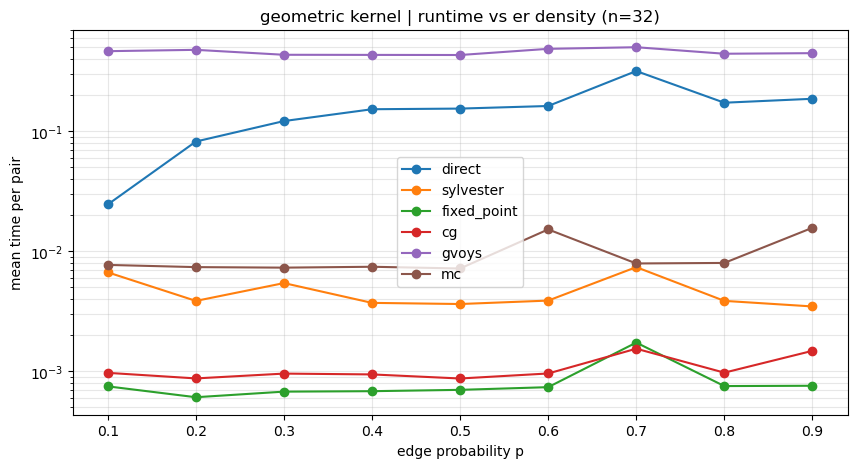

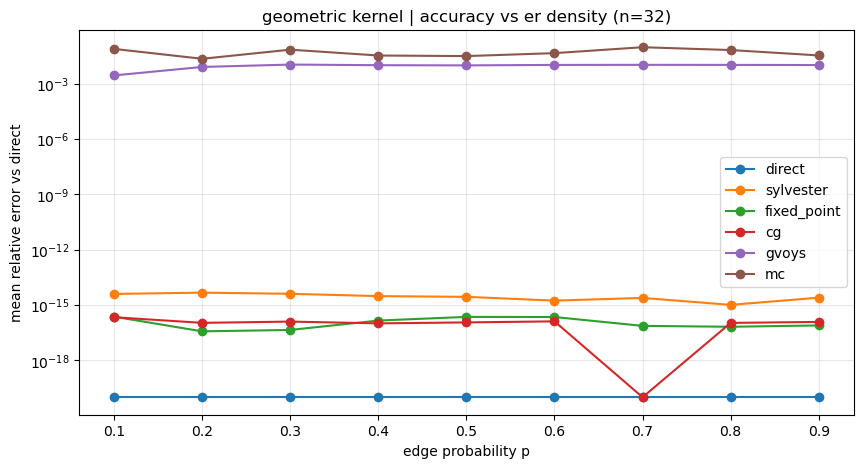

In [39]:
print_density_bench(density_experiment_geom)
plot_density_bench(density_experiment_geom)

### Labeled